# MHI Context Pilot

This disposable post hoc notebook tests whether a Pisl et al.-style Mental Health Index (MHI) attenuates the current ADHD/autism arousal trend.

The primary regression population is the current substantive-core target corpus (`clinical_only`, `lived_only`, and `mixed`). A raw-pool sensitivity uses all post-preprocessing ADHD/autism target mentions before the classifier screen. The MHI embedding space is trained once on all LSC mention contexts, including baseline terms, so the mental-health vector is not defined only inside ADHD/autism contexts.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from gensim.models import Word2Vec
from scipy import stats
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 180)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#263238",
        "axes.labelcolor": "#263238",
        "axes.titlecolor": "#263238",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#D7DEE2",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "legend.frameon": False,
        "xtick.color": "#263238",
        "ytick.color": "#263238",
    }
)


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from notebook working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
CONTEXT_PATH = PROJECT_ROOT / "data/interim/lsc/contexts/lsc_mention_contexts.parquet"
FRAME_LABEL_PATH = PROJECT_ROOT / "data/processed/lsc/classification/lsc_target_context_frame_labels.csv"
VAD_MATCH_PATH = PROJECT_ROOT / "data/interim/lsc/vad/lsc_vad_collocate_matches.parquet"
NRC_VAD_PATH = PROJECT_ROOT / "data/external/NRC-VAD-Lexicon-v2.1/NRC-VAD-Lexicon-v2.1.txt"

INTERIM_DIR = PROJECT_ROOT / "data/interim/lsc/mhi_pilot"
MODEL_DIR = INTERIM_DIR / "word2vec"
PROCESSED_DIR = PROJECT_ROOT / "data/processed/lsc/posthoc/mhi_pilot"
FIGURE_DIR = PROJECT_ROOT / "reports/figures/lsc/posthoc/mhi_pilot"
for directory in [INTERIM_DIR, MODEL_DIR, PROCESSED_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TOKENISED_CONTEXTS_PATH = INTERIM_DIR / "lsc_mhi_tokenised_contexts.parquet"
TOKENISED_MANIFEST_PATH = INTERIM_DIR / "lsc_mhi_tokenised_contexts_manifest.json"
MODEL_PATH = MODEL_DIR / "lsc_mhi_cbow_word2vec.model"
MODEL_MANIFEST_PATH = MODEL_DIR / "lsc_mhi_cbow_word2vec_manifest.json"
CONTEXT_SCORES_PATH = PROCESSED_DIR / "lsc_mhi_context_scores.parquet"
SEED_DIAGNOSTICS_PATH = PROCESSED_DIR / "lsc_mhi_seed_diagnostics.csv"
NEAREST_TERMS_PATH = PROCESSED_DIR / "lsc_mhi_nearest_terms.csv"
HIGH_LOW_VOCAB_PATH = PROCESSED_DIR / "lsc_mhi_high_low_vocabulary.csv"
PRIMARY_MODEL_INPUT_PATH = PROCESSED_DIR / "lsc_mhi_primary_context_model_input.parquet"
RAW_AROUSAL_PATH = INTERIM_DIR / "lsc_mhi_raw_target_context_arousal.parquet"
RAW_AROUSAL_COVERAGE_PATH = INTERIM_DIR / "lsc_mhi_raw_target_context_arousal_coverage.parquet"
RAW_MODEL_INPUT_PATH = PROCESSED_DIR / "lsc_mhi_raw_context_model_input.parquet"
ANNUAL_DIAGNOSTICS_PATH = PROCESSED_DIR / "lsc_mhi_annual_diagnostics.csv"
FRAME_DIAGNOSTICS_PATH = PROCESSED_DIR / "lsc_mhi_frame_diagnostics.csv"
MODEL_SUMMARY_PATH = PROCESSED_DIR / "lsc_mhi_model_summary.csv"
MODEL_COEFFICIENTS_PATH = PROCESSED_DIR / "lsc_mhi_model_coefficients.csv"
BOOTSTRAP_SUMMARY_PATH = PROCESSED_DIR / "lsc_mhi_slope_attenuation_bootstrap.csv"
EXECUTION_SUMMARY_PATH = PROCESSED_DIR / "lsc_mhi_execution_summary.json"
ANNUAL_FIGURE_PATH = FIGURE_DIR / "lsc_mhi_annual_mhi_arousal_diagnostics.png"
ANNUAL_FIGURE_PDF_PATH = FIGURE_DIR / "lsc_mhi_annual_mhi_arousal_diagnostics.pdf"

EXPECTED_YEARS = list(range(2014, 2027))
TARGET_UNITS = ["ADHD", "Autism"]
CORE_TARGET_FRAMES = ["clinical_only", "lived_only", "mixed"]
PISL_MENTAL_SEEDS = ["mental", "schizophrenia", "health", "disease", "drug", "therapy", "melancholia", "psychiatry", "psychology"]
TARGET_CONCEPT_TOKENS = {"adhd_concept", "autism_concept"}
TARGET_CONCEPT_TOKEN = {"ADHD": "adhd_concept", "Autism": "autism_concept"}
WORD2VEC_PARAMS = {
    "vector_size": 200,
    "window": 10,
    "min_count": 5,
    "sg": 0,
    "workers": 1,
    "seed": 13,
    "epochs": 10,
}
REBUILD_TOKENISED_CONTEXTS = False
REBUILD_WORD2VEC_MODEL = False
REBUILD_RAW_AROUSAL = False
TOKENISATION_CONFIG_VERSION = 1
MIN_CONTEXT_TOKENS_FOR_TRAINING = 3
BOOTSTRAP_REPETITIONS = 200
BOOTSTRAP_SEED = 123
LSC_FIGURE_DPI = 300

assert CONTEXT_PATH.exists(), CONTEXT_PATH
assert FRAME_LABEL_PATH.exists(), FRAME_LABEL_PATH
assert VAD_MATCH_PATH.exists(), VAD_MATCH_PATH
assert NRC_VAD_PATH.exists(), NRC_VAD_PATH

PROJECT_ROOT


/opt/anaconda3/envs/msc-nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/jakoblutkemeier/Documents/msc-nlp-therapy-speak')

## Load Context And Frame Inputs

The primary analysis uses the classifier-screened substantive core. The raw sensitivity keeps all ADHD/autism target mentions after the collection and preprocessing pipeline, then uses classifier labels only for diagnostics.


In [2]:
context_columns = [
    "doc_id",
    "url",
    "registered_domain",
    "term_role",
    "target_group",
    "analysis_unit",
    "raw_form",
    "matched_text",
    "mention_start_char",
    "mention_end_char",
    "collapsed_raw_forms",
    "collapsed_matched_texts",
    "target_sentence_plus_adjacent",
    "token_window_5",
    "published_year",
    "source_year",
    "lsc_year",
]
contexts = pd.read_parquet(CONTEXT_PATH, columns=context_columns).reset_index(drop=True)
contexts["source_context_row_id"] = contexts.index.astype(int)
contexts["registered_domain"] = contexts["registered_domain"].fillna("unknown_domain")

observed_years = sorted(contexts["lsc_year"].dropna().astype(int).unique())
missing_years = sorted(set(EXPECTED_YEARS) - set(observed_years))
if missing_years:
    raise RuntimeError(f"Missing expected LSC years from context table: {missing_years}")
if contexts["target_sentence_plus_adjacent"].fillna("").str.strip().eq("").any():
    raise RuntimeError("Some context rows have empty target_sentence_plus_adjacent values.")
if contexts["token_window_5"].fillna("").str.strip().eq("").any():
    raise RuntimeError("Some context rows have empty token_window_5 values.")


def stable_context_id(row: pd.Series) -> str:
    value = "|".join(
        str(row.get(column, ""))
        for column in ["doc_id", "analysis_unit", "raw_form", "mention_start_char", "mention_end_char"]
    )
    return hashlib.sha1(value.encode("utf-8")).hexdigest()[:16]


target_mask = contexts["analysis_unit"].isin(TARGET_UNITS)
contexts.loc[target_mask, "context_id"] = contexts.loc[target_mask].apply(stable_context_id, axis=1)
contexts.loc[~target_mask, "context_id"] = contexts.loc[~target_mask, "source_context_row_id"].map(lambda value: f"baseline_{value}")

label_columns = [
    "context_id",
    "predicted_derived_frame",
    "p_substantive",
    "p_clinical_given_substantive",
    "p_lived_given_substantive",
]
frame_labels = pd.read_csv(FRAME_LABEL_PATH, usecols=label_columns)
if frame_labels["context_id"].duplicated().any():
    raise RuntimeError("Frame-label handoff contains duplicate context IDs.")

contexts = contexts.merge(frame_labels, on="context_id", how="left")
missing_labels = contexts.loc[target_mask, "predicted_derived_frame"].isna().sum()
if missing_labels:
    raise RuntimeError(f"Missing classifier labels for {missing_labels:,} target contexts.")
contexts.loc[~target_mask, "predicted_derived_frame"] = "unframed_baseline"

input_summary = (
    contexts.groupby(["term_role", "analysis_unit", "predicted_derived_frame"], dropna=False)
    .agg(contexts=("source_context_row_id", "size"), documents=("doc_id", "nunique"))
    .reset_index()
    .sort_values(["term_role", "analysis_unit", "predicted_derived_frame"])
)
input_summary


,term_role,analysis_unit,predicted_derived_frame,contexts,documents
0,baseline,frustration,unframed_baseline,105482,93663
1,baseline,loneliness,unframed_baseline,38052,30431
2,baseline,sadness,unframed_baseline,53272,45283
3,target,ADHD,clinical_only,12039,8006
4,target,ADHD,lived_only,3610,2730
5,target,ADHD,mixed,2000,1634
6,target,ADHD,non_substantive_or_insufficient,10242,8221
7,target,ADHD,substantive_other,720,660
8,target,Autism,clinical_only,20306,12959
9,target,Autism,lived_only,12826,9068


## Tokenise MHI Corpus

The embedding corpus uses all LSC mention contexts. ADHD/autism surface forms are collapsed to concept tokens for training, but these concept tokens are excluded from each context's MHI score to reduce circularity.


In [3]:
# Use a fast, inspectable regex tokenizer for the MHI embedding corpus. The raw VAD
# sensitivity below still loads spaCy because NRC-VAD matching needs lemmatisation.
blank_nlp = spacy.blank("en")

TARGET_PATTERNS = [
    (re.compile(r"\battention\s+deficit(?:\s+hyperactivity(?:\s+disorder)?)?\b", flags=re.IGNORECASE), " adhd_concept "),
    (re.compile(r"\bADHD\b", flags=re.IGNORECASE), " adhd_concept "),
    (re.compile(r"\bautism\s+spectrum(?:\s+disorder)?\b", flags=re.IGNORECASE), " autism_concept "),
    (re.compile(r"\bASD\b", flags=re.IGNORECASE), " autism_concept "),
    (re.compile(r"\bautistic\b", flags=re.IGNORECASE), " autism_concept "),
    (re.compile(r"\bautism\b", flags=re.IGNORECASE), " autism_concept "),
]
WORD_RE = re.compile(r"[a-z_]+")
TOKEN_RE = re.compile(r"^[a-z_]+$")
CUSTOM_STOPWORDS = {
    "http", "https", "www", "com", "org", "net", "html", "php", "pdf",
    "website", "webpage", "page", "site", "menu", "click", "login", "subscribe",
    "newsletter", "cookie", "cookies", "copyright", "reserved", "email", "facebook",
    "twitter", "instagram", "pinterest", "google", "post", "posted", "share", "search",
    "read", "more", "learn", "home", "contact", "privacy", "policy", "terms",
}
STOPWORDS = set(blank_nlp.Defaults.stop_words) | CUSTOM_STOPWORDS


def canonicalise_text(text: object) -> str:
    canonical = str(text or "")
    for pattern, replacement in TARGET_PATTERNS:
        canonical = pattern.sub(replacement, canonical)
    return canonical.lower()


def regex_content_tokens(text: object) -> list[str]:
    tokens = []
    for token in WORD_RE.findall(canonicalise_text(text)):
        if token in TARGET_CONCEPT_TOKENS:
            tokens.append(token)
            continue
        if token in {"adhd", "add"}:
            tokens.append("adhd_concept")
            continue
        if token in {"autism", "autistic", "asd"}:
            tokens.append("autism_concept")
            continue
        if len(token) <= 2 or token in STOPWORDS:
            continue
        if not TOKEN_RE.match(token):
            continue
        tokens.append(token)
    return tokens


def tokenisation_manifest_for_contexts(frame: pd.DataFrame) -> dict[str, object]:
    digest = hashlib.sha256()
    for row in frame.sort_values("source_context_row_id").itertuples(index=False):
        digest.update(str(row.source_context_row_id).encode("utf-8"))
        digest.update(b"\0")
        digest.update(str(row.target_sentence_plus_adjacent or "").encode("utf-8"))
        digest.update(b"\0")
        digest.update(str(row.context_id).encode("utf-8"))
        digest.update(b"\0")
    return {
        "schema_version": 1,
        "tokenisation_config_version": TOKENISATION_CONFIG_VERSION,
        "tokeniser": "regex_lowercase_content_words",
        "contexts": int(len(frame)),
        "context_fingerprint": digest.hexdigest(),
        "target_regexes": [pattern.pattern for pattern, _ in TARGET_PATTERNS],
        "custom_stopwords": sorted(CUSTOM_STOPWORDS),
        "word_pattern": WORD_RE.pattern,
        "token_pattern": TOKEN_RE.pattern,
        "target_concept_tokens": sorted(TARGET_CONCEPT_TOKENS),
    }


expected_tokenised_manifest = tokenisation_manifest_for_contexts(contexts)
token_cache_status = "created_cache"
if not REBUILD_TOKENISED_CONTEXTS and TOKENISED_CONTEXTS_PATH.exists() and TOKENISED_MANIFEST_PATH.exists():
    observed_manifest = json.loads(TOKENISED_MANIFEST_PATH.read_text())
    if observed_manifest == expected_tokenised_manifest:
        tokenised_contexts = pd.read_parquet(TOKENISED_CONTEXTS_PATH)
        token_cache_status = "loaded_cache"
    else:
        tokenised_contexts = None
else:
    tokenised_contexts = None

if tokenised_contexts is None:
    token_records = []
    for row in tqdm(contexts.itertuples(index=False), total=len(contexts), desc="Tokenising MHI contexts"):
        tokens = regex_content_tokens(row.target_sentence_plus_adjacent)
        scored_candidate_tokens = [token for token in tokens if token not in TARGET_CONCEPT_TOKENS]
        token_records.append(
            {
                "source_context_row_id": int(row.source_context_row_id),
                "context_id": row.context_id,
                "doc_id": row.doc_id,
                "registered_domain": row.registered_domain,
                "analysis_unit": row.analysis_unit,
                "term_role": row.term_role,
                "target_group": row.target_group,
                "lsc_year": int(row.lsc_year),
                "predicted_derived_frame": row.predicted_derived_frame,
                "tokens": tokens,
                "token_count": len(tokens),
                "scored_candidate_token_count": len(scored_candidate_tokens),
            }
        )
    tokenised_contexts = pd.DataFrame(token_records)
    tokenised_contexts.to_parquet(TOKENISED_CONTEXTS_PATH, index=False)
    TOKENISED_MANIFEST_PATH.write_text(json.dumps(expected_tokenised_manifest, indent=2, sort_keys=True) + "\n")

training_sentences = tokenised_contexts.loc[tokenised_contexts["token_count"].ge(MIN_CONTEXT_TOKENS_FOR_TRAINING), "tokens"].tolist()
if not training_sentences:
    raise RuntimeError("No tokenised contexts are available for MHI word2vec training.")

token_summary = {
    "token_cache_status": token_cache_status,
    "tokenised_contexts": int(len(tokenised_contexts)),
    "training_sentences": int(len(training_sentences)),
    "total_training_tokens": int(sum(len(sentence) for sentence in training_sentences)),
}
token_summary


Tokenising MHI contexts:   0%|          | 0/293670 [00:00<?, ?it/s]

Tokenising MHI contexts:   0%|          | 1273/293670 [00:00<00:22, 12719.10it/s]

Tokenising MHI contexts:   1%|          | 2545/293670 [00:00<00:22, 12697.83it/s]

Tokenising MHI contexts:   1%|▏         | 3936/293670 [00:00<00:21, 13250.24it/s]

Tokenising MHI contexts:   2%|▏         | 5358/293670 [00:00<00:21, 13632.17it/s]

...

Tokenising MHI contexts:  99%|█████████▉| 290027/293670 [00:20<00:00, 14641.65it/s]

Tokenising MHI contexts:  99%|█████████▉| 291738/293670 [00:20<00:00, 15364.28it/s]

Tokenising MHI contexts: 100%|█████████▉| 293380/293670 [00:20<00:00, 15676.21it/s]

Tokenising MHI contexts: 100%|██████████| 293670/293670 [00:20<00:00, 14478.50it/s]

{'token_cache_status': 'created_cache',
 'tokenised_contexts': 293670,
 'training_sentences': 293636,
 'total_training_tokens': 10833316}

## Train Or Load CBOW Model

This uses a single CBOW model, not the existing thematic skip-gram models. The goal is a Pisl-style corpus-level mental-health-proximity index, not target-specific semantic-neighbour trajectories.


In [4]:
def fingerprint_sentences(sentences: list[list[str]]) -> str:
    digest = hashlib.sha256()
    for sentence in sentences:
        digest.update(" ".join(sentence).encode("utf-8"))
        digest.update(b"\0")
    return digest.hexdigest()


expected_model_manifest = {
    "schema_version": 1,
    "model_type": "gensim_word2vec_cbow",
    "word2vec_params": WORD2VEC_PARAMS,
    "training_sentences": int(len(training_sentences)),
    "training_sentence_fingerprint": fingerprint_sentences(training_sentences),
    "tokenised_manifest": expected_tokenised_manifest,
}

model_cache_status = "trained"
if not REBUILD_WORD2VEC_MODEL and MODEL_PATH.exists() and MODEL_MANIFEST_PATH.exists():
    observed_model_manifest = json.loads(MODEL_MANIFEST_PATH.read_text())
    if observed_model_manifest == expected_model_manifest:
        mhi_model = Word2Vec.load(str(MODEL_PATH))
        model_cache_status = "loaded_cache"
    else:
        mhi_model = None
else:
    mhi_model = None

if mhi_model is None:
    mhi_model = Word2Vec(
        sentences=training_sentences,
        vector_size=WORD2VEC_PARAMS["vector_size"],
        window=WORD2VEC_PARAMS["window"],
        min_count=WORD2VEC_PARAMS["min_count"],
        sg=WORD2VEC_PARAMS["sg"],
        workers=WORD2VEC_PARAMS["workers"],
        seed=WORD2VEC_PARAMS["seed"],
        epochs=WORD2VEC_PARAMS["epochs"],
    )
    mhi_model.save(str(MODEL_PATH))
    MODEL_MANIFEST_PATH.write_text(json.dumps(expected_model_manifest, indent=2, sort_keys=True) + "\n")

model_summary = {
    "model_cache_status": model_cache_status,
    "corpus_count": int(mhi_model.corpus_count),
    "vocabulary_size": int(len(mhi_model.wv)),
}
model_summary


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


{'model_cache_status': 'trained',
 'corpus_count': 293636,
 'vocabulary_size': 60173}

## Calculate MHI Scores

MHI is the mean cosine similarity between scored context tokens and the averaged Pisl mental-health seed vector. ADHD/autism concept tokens are excluded from scoring.


In [5]:
seed_rows = []
present_seed_vectors = []
for seed in PISL_MENTAL_SEEDS:
    in_vocab = seed in mhi_model.wv
    count = int(mhi_model.wv.get_vecattr(seed, "count")) if in_vocab else 0
    seed_rows.append({"seed": seed, "in_vocabulary": in_vocab, "corpus_count": count})
    if in_vocab:
        present_seed_vectors.append(mhi_model.wv[seed])

seed_diagnostics = pd.DataFrame(seed_rows)
seed_diagnostics.to_csv(SEED_DIAGNOSTICS_PATH, index=False)
if len(present_seed_vectors) < 3:
    raise RuntimeError(f"Too few Pisl MHI seeds are present in the local CBOW vocabulary: {seed_diagnostics}")

mental_vector = np.vstack(present_seed_vectors).mean(axis=0)
mental_vector_norm = float(np.linalg.norm(mental_vector))
if not mental_vector_norm:
    raise RuntimeError("Mental-health reference vector has zero norm.")

nearest_terms = pd.DataFrame(
    [
        {"rank": rank, "term": term, "cosine_similarity": float(similarity)}
        for rank, (term, similarity) in enumerate(mhi_model.wv.similar_by_vector(mental_vector, topn=30), start=1)
    ]
)
nearest_terms.to_csv(NEAREST_TERMS_PATH, index=False)

similarity_by_token: dict[str, float] = {}
for token in mhi_model.wv.index_to_key:
    vector = mhi_model.wv[token]
    denominator = float(np.linalg.norm(vector) * mental_vector_norm)
    similarity_by_token[token] = float(np.dot(vector, mental_vector) / denominator) if denominator else np.nan

score_rows = []
for row in tqdm(tokenised_contexts.itertuples(index=False), total=len(tokenised_contexts), desc="Scoring context MHI"):
    scored_tokens = [token for token in row.tokens if token not in TARGET_CONCEPT_TOKENS and token in similarity_by_token]
    scores = [similarity_by_token[token] for token in scored_tokens]
    score_rows.append(
        {
            "source_context_row_id": int(row.source_context_row_id),
            "context_id": row.context_id,
            "doc_id": row.doc_id,
            "registered_domain": row.registered_domain,
            "analysis_unit": row.analysis_unit,
            "term_role": row.term_role,
            "target_group": row.target_group,
            "lsc_year": int(row.lsc_year),
            "predicted_derived_frame": row.predicted_derived_frame,
            "mhi": float(np.mean(scores)) if scores else np.nan,
            "mhi_scored_tokens": len(scores),
            "mhi_candidate_tokens": int(row.scored_candidate_token_count),
            "mhi_in_vocab_coverage": len(scores) / row.scored_candidate_token_count if row.scored_candidate_token_count else np.nan,
            "token_count": int(row.token_count),
        }
    )

context_scores = pd.DataFrame(score_rows)
context_scores.to_parquet(CONTEXT_SCORES_PATH, index=False)

mhi_score_summary = (
    context_scores.groupby(["term_role", "analysis_unit"], as_index=False)
    .agg(
        contexts=("source_context_row_id", "size"),
        scored_contexts=("mhi", "count"),
        mean_mhi=("mhi", "mean"),
        median_scored_tokens=("mhi_scored_tokens", "median"),
        mean_in_vocab_coverage=("mhi_in_vocab_coverage", "mean"),
    )
)
seed_diagnostics, nearest_terms.head(20), mhi_score_summary


Scoring context MHI:   0%|          | 0/293670 [00:00<?, ?it/s]

Scoring context MHI:   2%|▏         | 5018/293670 [00:00<00:05, 50173.11it/s]

Scoring context MHI:   3%|▎         | 10268/293670 [00:00<00:05, 51539.00it/s]

Scoring context MHI:   5%|▌         | 15850/293670 [00:00<00:05, 53489.80it/s]

Scoring context MHI:   7%|▋         | 21381/293670 [00:00<00:05, 54206.62it/s]

...

Scoring context MHI:  95%|█████████▌| 279086/293670 [00:05<00:00, 45706.24it/s]

Scoring context MHI:  97%|█████████▋| 283968/293670 [00:05<00:00, 46570.84it/s]

Scoring context MHI:  98%|█████████▊| 289064/293670 [00:05<00:00, 47816.56it/s]

Scoring context MHI: 100%|██████████| 293670/293670 [00:05<00:00, 51830.23it/s]

(            seed  in_vocabulary  corpus_count
 0         mental           True         18322
 1  schizophrenia           True          1922
 2         health           True         31627
 3        disease           True          7902
 4           drug           True          4135
 5        therapy           True         12729
 6    melancholia           True            61
 7     psychiatry           True          1248
 8     psychology           True          2578,
     rank                term  cosine_similarity
 0      1          psychiatry           0.627164
 1      2        psychosocial           0.600994
 2      3         psychiatric           0.582759
 3      4       schizophrenia           0.566604
 4      5          psychology           0.557085
 5      6     psychopathology           0.556056
 6      7           disorders           0.547165
 7      8             therapy           0.528688
 8      9       psychotherapy           0.523984
 9     10      neurocognitive          

## Vocabulary Check For High And Low MHI Contexts

This is a disposable validation check: high-MHI target contexts should contain recognisably mental-health-related vocabulary, not just the focal ADHD/autism terms.


In [6]:
target_scores = context_scores.loc[context_scores["analysis_unit"].isin(TARGET_UNITS) & context_scores["mhi"].notna()].copy()
low_threshold = target_scores["mhi"].quantile(0.25)
high_threshold = target_scores["mhi"].quantile(0.75)
band_lookup = target_scores[["source_context_row_id", "mhi"]].copy()
band_lookup["mhi_band"] = np.select(
    [band_lookup["mhi"].le(low_threshold), band_lookup["mhi"].ge(high_threshold)],
    ["low_mhi", "high_mhi"],
    default="middle_mhi",
)

token_bands = tokenised_contexts.merge(band_lookup[["source_context_row_id", "mhi_band"]], on="source_context_row_id", how="inner")
vocab_records = []
for band in ["high_mhi", "low_mhi"]:
    counter = Counter(
        token
        for tokens in token_bands.loc[token_bands["mhi_band"].eq(band), "tokens"]
        for token in tokens
        if token not in TARGET_CONCEPT_TOKENS and token in similarity_by_token
    )
    total = sum(counter.values())
    for rank, (token, count) in enumerate(counter.most_common(40), start=1):
        vocab_records.append({"mhi_band": band, "rank": rank, "token": token, "count": int(count), "token_share": count / total if total else np.nan})

high_low_vocab = pd.DataFrame(vocab_records)
high_low_vocab.to_csv(HIGH_LOW_VOCAB_PATH, index=False)
high_low_vocab.head(20)


,mhi_band,rank,token,count,token_share
0,high_mhi,1,children,13935,0.013838
1,high_mhi,2,disorders,13052,0.012962
2,high_mhi,3,disorder,11866,0.011784
3,high_mhi,4,health,10783,0.010708
4,high_mhi,5,mental,6938,0.006890
5,high_mhi,6,therapy,6243,0.006200
6,high_mhi,7,depression,5953,0.005912
7,high_mhi,8,anxiety,5905,0.005864
8,high_mhi,9,treatment,5636,0.005597
9,high_mhi,10,child,5527,0.005489


## Primary Context Arousal Table

The primary table reuses the existing NRC-VAD handoff and takes only `substantive_core_overall`, preserving the current reported arousal population.


In [7]:
vad_columns = [
    "context_row_id",
    "source_context_row_id",
    "context_id",
    "doc_id",
    "lsc_year",
    "analysis_unit",
    "term_role",
    "target_group",
    "raw_form",
    "frame_stratum",
    "predicted_derived_frame",
    "registered_domain",
    "arousal",
    "valence",
    "dominance",
]
vad_matches = pd.read_parquet(VAD_MATCH_PATH, columns=vad_columns)
primary_matches = vad_matches.loc[
    vad_matches["analysis_unit"].isin(TARGET_UNITS) & vad_matches["frame_stratum"].eq("substantive_core_overall")
].copy()

primary_arousal = (
    primary_matches.groupby(
        [
            "source_context_row_id",
            "context_id",
            "doc_id",
            "lsc_year",
            "analysis_unit",
            "term_role",
            "target_group",
            "predicted_derived_frame",
            "registered_domain",
        ],
        as_index=False,
    )
    .agg(
        context_arousal_mean=("arousal", "mean"),
        context_valence_mean_for_reference=("valence", "mean"),
        matched_vad_units=("arousal", "size"),
    )
)

primary_model_input = primary_arousal.merge(
    context_scores[["source_context_row_id", "mhi", "mhi_scored_tokens", "mhi_in_vocab_coverage", "token_count"]],
    on="source_context_row_id",
    how="left",
)
primary_model_input["model_population"] = "substantive_core"
primary_model_input = primary_model_input.dropna(subset=["context_arousal_mean", "mhi"]).reset_index(drop=True)
primary_model_input.to_parquet(PRIMARY_MODEL_INPUT_PATH, index=False)

primary_input_summary = (
    primary_model_input.groupby(["analysis_unit", "predicted_derived_frame"], as_index=False)
    .agg(
        contexts=("source_context_row_id", "size"),
        documents=("doc_id", "nunique"),
        mean_arousal=("context_arousal_mean", "mean"),
        mean_mhi=("mhi", "mean"),
        median_mhi_tokens=("mhi_scored_tokens", "median"),
    )
)
primary_input_summary


,analysis_unit,predicted_derived_frame,contexts,documents,mean_arousal,mean_mhi,median_mhi_tokens
0,ADHD,clinical_only,11924,7982,-0.017204,0.150167,31.0
1,ADHD,lived_only,3601,2728,-0.039872,0.028769,25.0
2,ADHD,mixed,1992,1627,-0.030736,0.076190,28.0
3,Autism,clinical_only,20289,12955,-0.012134,0.118449,32.0
4,Autism,lived_only,12819,9066,-0.044747,0.009828,27.0
5,Autism,mixed,6330,4734,-0.039493,0.066697,31.0


## Raw-Pool Arousal Sensitivity

The raw sensitivity reconstructs a minimal context-level arousal table for all ADHD/autism target mentions, including mentions later classified as non-substantive or substantive-other.


In [8]:

try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
except OSError as exc:
    raise RuntimeError("spaCy model en_core_web_sm is required for raw-pool NRC-VAD arousal scoring.") from exc

TARGET_RAW_FORM_EXCLUSION_TOKENS = {
    "adhd": {"adhd"},
    "attention_deficit": {"attention", "deficit", "hyperactivity", "disorder"},
    "autism": {"autism"},
    "autistic": {"autistic"},
    "autism_spectrum": {"autism", "spectrum"},
    "asd_disambiguated": {"asd"},
}


def split_pipe_values(value: object) -> list[str]:
    if pd.isna(value):
        return []
    return [part.strip() for part in str(value).split("|") if part.strip()]


def exclusion_tokens_for_row(row: pd.Series) -> set[str]:
    raw_forms = {str(row["raw_form"])} | set(split_pipe_values(row.get("collapsed_raw_forms")))
    tokens: set[str] = set()
    for raw_form in raw_forms:
        tokens.update(TARGET_RAW_FORM_EXCLUSION_TOKENS.get(raw_form, {raw_form.replace("_", " ")}))
    matched_text = str(row.get("matched_text") or "")
    if matched_text:
        tokens.update(part.lower() for part in re.findall(r"[A-Za-z]+", matched_text))
    return tokens


def prepare_vad_lookup() -> tuple[dict[tuple[str, ...], object], dict[tuple[str, ...], object], list[int]]:
    vad = pd.read_csv(NRC_VAD_PATH, sep="\t")
    expected_vad_columns = {"term", "valence", "arousal", "dominance"}
    if set(vad.columns) != expected_vad_columns:
        raise RuntimeError(f"Unexpected NRC-VAD columns: {vad.columns.tolist()}")
    for column in ["valence", "arousal", "dominance"]:
        if not vad[column].between(-1, 1).all():
            raise RuntimeError(f"NRC-VAD {column} values outside expected [-1, 1] range.")

    lexicon_records = []
    vad_terms = vad["term"].fillna("").map(str).tolist()
    for doc, row in zip(nlp.pipe(vad_terms, batch_size=1000), vad.itertuples(index=False)):
        lemma_tokens = [token.lemma_.lower() for token in doc if token.is_alpha and len(token.lemma_) > 1]
        if not lemma_tokens:
            continue
        lexicon_records.append(
            {
                "lexicon_key": " ".join(lemma_tokens),
                "lexicon_tuple": tuple(lemma_tokens),
                "lexicon_length": len(lemma_tokens),
                "term": row.term,
                "valence": float(row.valence),
                "arousal": float(row.arousal),
                "dominance": float(row.dominance),
            }
        )
    lexicon = pd.DataFrame(lexicon_records)
    lexicon_lookup = (
        lexicon.groupby(["lexicon_key", "lexicon_length"], as_index=False)
        .agg(
            valence=("valence", "mean"),
            arousal=("arousal", "mean"),
            dominance=("dominance", "mean"),
            source_terms=("term", lambda values: " | ".join(sorted(set(values))[:5])),
            source_term_count=("term", "nunique"),
        )
    )
    lexicon_lookup["lexicon_tuple"] = lexicon_lookup["lexicon_key"].str.split().map(tuple)
    unigram_lookup = {
        row.lexicon_tuple: row
        for row in lexicon_lookup.loc[lexicon_lookup["lexicon_length"].eq(1)].itertuples(index=False)
    }
    mwe_lookup = {
        row.lexicon_tuple: row
        for row in lexicon_lookup.loc[lexicon_lookup["lexicon_length"].gt(1)].itertuples(index=False)
    }
    mwe_lengths = sorted({len(key) for key in mwe_lookup}, reverse=True)
    return unigram_lookup, mwe_lookup, mwe_lengths


def lexical_tokens(doc: spacy.tokens.Doc, excluded_terms: set[str]) -> list[dict[str, object]]:
    tokens = []
    for token in doc:
        lemma = token.lemma_.lower()
        lower = token.text.lower()
        if not token.is_alpha or token.like_num or len(lemma) <= 1:
            continue
        if lemma in excluded_terms or lower in excluded_terms:
            continue
        tokens.append({"token_index": token.i, "text": token.text, "lemma": lemma})
    return tokens


def match_vad_units(tokens: list[dict[str, object]], unigram_lookup, mwe_lookup, mwe_lengths) -> list[dict[str, object]]:
    matches = []
    index = 0
    while index < len(tokens):
        matched = None
        for length in mwe_lengths:
            if index + length > len(tokens):
                continue
            key = tuple(token["lemma"] for token in tokens[index : index + length])
            if key in mwe_lookup:
                matched = (length, mwe_lookup[key])
                break
        if matched is None:
            key = (tokens[index]["lemma"],)
            if key in unigram_lookup:
                matched = (1, unigram_lookup[key])
        if matched is None:
            index += 1
            continue
        length, lexicon_row = matched
        matches.append(
            {
                "matched_token_count": int(length),
                "valence": float(lexicon_row.valence),
                "arousal": float(lexicon_row.arousal),
                "dominance": float(lexicon_row.dominance),
            }
        )
        index += length
    return matches


if not REBUILD_RAW_AROUSAL and RAW_AROUSAL_PATH.exists() and RAW_AROUSAL_COVERAGE_PATH.exists():
    raw_arousal = pd.read_parquet(RAW_AROUSAL_PATH)
    raw_arousal_coverage = pd.read_parquet(RAW_AROUSAL_COVERAGE_PATH)
    raw_arousal_cache_status = "loaded_cache"
else:
    raw_arousal_cache_status = "created_cache"
    unigram_lookup, mwe_lookup, mwe_lengths = prepare_vad_lookup()
    raw_target_contexts = contexts.loc[contexts["analysis_unit"].isin(TARGET_UNITS)].copy()
    raw_rows = []
    coverage_rows = []
    iterator = zip(
        nlp.pipe(raw_target_contexts["token_window_5"].astype(str), batch_size=1000),
        raw_target_contexts.iterrows(),
    )
    for doc, (_, row) in tqdm(iterator, total=len(raw_target_contexts), desc="Scoring raw-pool target arousal"):
        tokens = lexical_tokens(doc, exclusion_tokens_for_row(row))
        matches = match_vad_units(tokens, unigram_lookup, mwe_lookup, mwe_lengths)
        matched_units = len(matches)
        matched_token_positions = int(sum(match["matched_token_count"] for match in matches))
        coverage_rows.append(
            {
                "source_context_row_id": int(row["source_context_row_id"]),
                "context_id": row["context_id"],
                "doc_id": row["doc_id"],
                "lsc_year": int(row["lsc_year"]),
                "analysis_unit": row["analysis_unit"],
                "target_group": row["target_group"],
                "raw_form": row["raw_form"],
                "predicted_derived_frame": row["predicted_derived_frame"],
                "candidate_collocate_tokens": len(tokens),
                "matched_vad_units": matched_units,
                "matched_token_positions": matched_token_positions,
                "has_vad_match": bool(matches),
            }
        )
        if matches:
            raw_rows.append(
                {
                    "source_context_row_id": int(row["source_context_row_id"]),
                    "context_id": row["context_id"],
                    "doc_id": row["doc_id"],
                    "lsc_year": int(row["lsc_year"]),
                    "analysis_unit": row["analysis_unit"],
                    "target_group": row["target_group"],
                    "raw_form": row["raw_form"],
                    "predicted_derived_frame": row["predicted_derived_frame"],
                    "registered_domain": row["registered_domain"],
                    "context_arousal_mean": float(np.mean([match["arousal"] for match in matches])),
                    "context_valence_mean_for_reference": float(np.mean([match["valence"] for match in matches])),
                    "matched_vad_units": matched_units,
                }
            )
    raw_arousal = pd.DataFrame(raw_rows)
    raw_arousal_coverage = pd.DataFrame(coverage_rows)
    raw_arousal.to_parquet(RAW_AROUSAL_PATH, index=False)
    raw_arousal_coverage.to_parquet(RAW_AROUSAL_COVERAGE_PATH, index=False)

raw_model_input = raw_arousal.merge(
    context_scores[["source_context_row_id", "mhi", "mhi_scored_tokens", "mhi_in_vocab_coverage", "token_count"]],
    on="source_context_row_id",
    how="left",
)
raw_model_input["model_population"] = "raw_target_pool"
raw_model_input = raw_model_input.dropna(subset=["context_arousal_mean", "mhi"]).reset_index(drop=True)
raw_model_input.to_parquet(RAW_MODEL_INPUT_PATH, index=False)

raw_input_summary = (
    raw_model_input.groupby(["analysis_unit", "predicted_derived_frame"], as_index=False)
    .agg(
        contexts=("source_context_row_id", "size"),
        documents=("doc_id", "nunique"),
        mean_arousal=("context_arousal_mean", "mean"),
        mean_mhi=("mhi", "mean"),
        median_mhi_tokens=("mhi_scored_tokens", "median"),
    )
)
raw_arousal_cache_status, raw_input_summary


Scoring raw-pool target arousal:   0%|          | 0/96864 [00:00<?, ?it/s]

Scoring raw-pool target arousal:   0%|          | 1/96864 [00:00<22:19:19,  1.21it/s]

Scoring raw-pool target arousal:   0%|          | 296/96864 [00:00<03:42, 434.25it/s]

Scoring raw-pool target arousal:   1%|          | 612/96864 [00:01<01:46, 906.68it/s]

Scoring raw-pool target arousal:   1%|          | 936/96864 [00:01<01:10, 1368.59it/s]

...

Scoring raw-pool target arousal:  99%|█████████▉| 95769/96864 [01:33<00:00, 1189.58it/s]

Scoring raw-pool target arousal:  99%|█████████▉| 96086/96864 [01:34<00:00, 852.65it/s] 

Scoring raw-pool target arousal: 100%|█████████▉| 96529/96864 [01:34<00:00, 1160.75it/s]

Scoring raw-pool target arousal: 100%|██████████| 96864/96864 [01:34<00:00, 1022.33it/s]

('created_cache',
   analysis_unit          predicted_derived_frame  contexts  documents  \
 0          ADHD                    clinical_only     11924       7982   
 1          ADHD                       lived_only      3601       2728   
 2          ADHD                            mixed      1992       1627   
 3          ADHD  non_substantive_or_insufficient     10175       8177   
 4          ADHD                substantive_other       718        658   
 5        Autism                    clinical_only     20289      12955   
 6        Autism                       lived_only     12819       9066   
 7        Autism                            mixed      6330       4734   
 8        Autism  non_substantive_or_insufficient     26452      20265   
 9        Autism                substantive_other      2277       1919   
 
    mean_arousal  mean_mhi  median_mhi_tokens  
 0     -0.017204  0.150167               31.0  
 1     -0.039872  0.028769               25.0  
 2     -0.030736  0.07

## Diagnostics By Year And Frame

These tables check whether MHI changes over time and whether it mainly reproduces the existing frame split.


In [9]:
all_model_input = pd.concat([primary_model_input, raw_model_input], ignore_index=True, sort=False)

annual_diagnostics = (
    all_model_input.groupby(["model_population", "analysis_unit", "lsc_year"], as_index=False)
    .agg(
        contexts=("source_context_row_id", "size"),
        documents=("doc_id", "nunique"),
        arousal_mean=("context_arousal_mean", "mean"),
        arousal_sd=("context_arousal_mean", "std"),
        mhi_mean=("mhi", "mean"),
        mhi_sd=("mhi", "std"),
        median_mhi_tokens=("mhi_scored_tokens", "median"),
        mean_mhi_in_vocab_coverage=("mhi_in_vocab_coverage", "mean"),
    )
    .sort_values(["model_population", "analysis_unit", "lsc_year"])
)
annual_diagnostics.to_csv(ANNUAL_DIAGNOSTICS_PATH, index=False)

frame_diagnostics = (
    all_model_input.groupby(["model_population", "analysis_unit", "predicted_derived_frame"], as_index=False)
    .agg(
        contexts=("source_context_row_id", "size"),
        documents=("doc_id", "nunique"),
        arousal_mean=("context_arousal_mean", "mean"),
        mhi_mean=("mhi", "mean"),
        mhi_sd=("mhi", "std"),
        median_mhi_tokens=("mhi_scored_tokens", "median"),
    )
    .sort_values(["model_population", "analysis_unit", "predicted_derived_frame"])
)
frame_diagnostics.to_csv(FRAME_DIAGNOSTICS_PATH, index=False)

annual_diagnostics.head(), frame_diagnostics


(  model_population analysis_unit  lsc_year  contexts  documents  arousal_mean  \
 0  raw_target_pool          ADHD      2014      3096       1825     -0.014567   
 1  raw_target_pool          ADHD      2015      2328       1475     -0.026384   
 2  raw_target_pool          ADHD      2016      2667       1792     -0.015909   
 3  raw_target_pool          ADHD      2017      2498       1657     -0.011154   
 4  raw_target_pool          ADHD      2018      2692       1754     -0.019371   
 
    arousal_sd  mhi_mean    mhi_sd  median_mhi_tokens  \
 0    0.139689  0.097981  0.090942               33.0   
 1    0.138909  0.109818  0.091748               30.0   
 2    0.139287  0.106214  0.094708               31.0   
 3    0.151720  0.100092  0.096565               31.0   
 4    0.141784  0.105840  0.091067               30.0   
 
    mean_mhi_in_vocab_coverage  
 0                    0.984798  
 1                    0.980439  
 2                    0.983556  
 3                    0.984734

## Context-Level Regression Models

The dependent variable is context-level mean NRC-VAD arousal. MHI is z-scored within each fitted model so the MHI coefficient is per within-model standard deviation; the year coefficient remains a per-year slope.


In [10]:
def fit_linear_model(
    data: pd.DataFrame,
    *,
    include_mhi: bool,
    include_frame: bool,
    frame_reference: str = "clinical_only",
) -> tuple[dict[str, object], pd.DataFrame]:
    required_columns = ["context_arousal_mean", "lsc_year"]
    if include_mhi:
        required_columns.append("mhi")
    if include_frame:
        required_columns.append("predicted_derived_frame")
    frame = data.dropna(subset=required_columns).copy()
    if len(frame) < 20:
        raise ValueError("Too few rows for a stable context-level model.")

    y = frame["context_arousal_mean"].to_numpy(dtype=float)
    design_columns = [np.ones(len(frame), dtype=float)]
    column_names = ["intercept"]

    year_center = float(frame["lsc_year"].mean())
    design_columns.append(frame["lsc_year"].to_numpy(dtype=float) - year_center)
    column_names.append("year_centered")

    mhi_center = np.nan
    mhi_scale = np.nan
    if include_mhi:
        mhi_values = frame["mhi"].to_numpy(dtype=float)
        mhi_center = float(np.mean(mhi_values))
        mhi_scale = float(np.std(mhi_values, ddof=1))
        if not mhi_scale:
            raise ValueError("MHI has zero variance in this model frame.")
        design_columns.append((mhi_values - mhi_center) / mhi_scale)
        column_names.append("mhi_z")

    frame_levels: list[str] = []
    if include_frame:
        observed_levels = sorted(frame["predicted_derived_frame"].dropna().unique())
        if frame_reference in observed_levels:
            frame_levels = [level for level in observed_levels if level != frame_reference]
            reference = frame_reference
        else:
            reference = observed_levels[0]
            frame_levels = observed_levels[1:]
        for level in frame_levels:
            design_columns.append(frame["predicted_derived_frame"].eq(level).astype(float).to_numpy())
            column_names.append(f"frame__{level}")
    else:
        reference = "not_applicable"

    x = np.column_stack(design_columns)
    beta, residuals, rank, _ = np.linalg.lstsq(x, y, rcond=None)
    fitted = x @ beta
    residual = y - fitted
    n_obs, n_parameters = x.shape
    df_resid = n_obs - n_parameters
    sse = float(np.sum(residual**2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r_squared = 1 - sse / sst if sst else np.nan
    adj_r_squared = 1 - (1 - r_squared) * (n_obs - 1) / df_resid if df_resid > 0 and not np.isnan(r_squared) else np.nan
    sigma2 = sse / df_resid if df_resid > 0 else np.nan
    try:
        covariance = sigma2 * np.linalg.inv(x.T @ x)
        standard_errors = np.sqrt(np.diag(covariance))
    except np.linalg.LinAlgError:
        standard_errors = np.full(n_parameters, np.nan)
    t_values = beta / standard_errors
    p_values = 2 * stats.t.sf(np.abs(t_values), df=df_resid) if df_resid > 0 else np.full(n_parameters, np.nan)

    coefficient_table = pd.DataFrame(
        {
            "coefficient": column_names,
            "estimate": beta,
            "standard_error": standard_errors,
            "t_value": t_values,
            "p_value": p_values,
        }
    )
    coefficients = coefficient_table.set_index("coefficient")
    summary = {
        "n_contexts": int(n_obs),
        "n_documents": int(frame["doc_id"].nunique()),
        "n_parameters": int(n_parameters),
        "df_resid": int(df_resid),
        "year_center": year_center,
        "mhi_center": mhi_center,
        "mhi_scale": mhi_scale,
        "frame_reference": reference,
        "r_squared": float(r_squared),
        "adj_r_squared": float(adj_r_squared),
        "year_slope_per_year": float(coefficients.loc["year_centered", "estimate"]),
        "year_slope_se": float(coefficients.loc["year_centered", "standard_error"]),
        "year_slope_p_value": float(coefficients.loc["year_centered", "p_value"]),
        "mhi_z_coefficient": float(coefficients.loc["mhi_z", "estimate"]) if "mhi_z" in coefficients.index else np.nan,
        "mhi_z_p_value": float(coefficients.loc["mhi_z", "p_value"]) if "mhi_z" in coefficients.index else np.nan,
    }
    return summary, coefficient_table


model_summary_rows = []
coefficient_rows = []

def add_model(
    frame: pd.DataFrame,
    *,
    model_population: str,
    analysis_unit: str,
    model_scope: str,
    formula_name: str,
    include_mhi: bool,
    include_frame: bool,
) -> None:
    summary, coefficients = fit_linear_model(frame, include_mhi=include_mhi, include_frame=include_frame)
    metadata = {
        "model_population": model_population,
        "analysis_unit": analysis_unit,
        "model_scope": model_scope,
        "formula_name": formula_name,
        "dependent_variable": "context_arousal_mean",
    }
    model_summary_rows.append({**metadata, **summary})
    for row in coefficients.itertuples(index=False):
        coefficient_rows.append({**metadata, **row._asdict()})


for population, population_frame in [("substantive_core", primary_model_input), ("raw_target_pool", raw_model_input)]:
    for unit, unit_frame in population_frame.groupby("analysis_unit", sort=True):
        add_model(
            unit_frame,
            model_population=population,
            analysis_unit=unit,
            model_scope="overall",
            formula_name="arousal ~ year",
            include_mhi=False,
            include_frame=False,
        )
        add_model(
            unit_frame,
            model_population=population,
            analysis_unit=unit,
            model_scope="overall",
            formula_name="arousal ~ year + MHI",
            include_mhi=True,
            include_frame=False,
        )
        if population == "substantive_core":
            add_model(
                unit_frame,
                model_population=population,
                analysis_unit=unit,
                model_scope="overall",
                formula_name="arousal ~ year + frame",
                include_mhi=False,
                include_frame=True,
            )
            add_model(
                unit_frame,
                model_population=population,
                analysis_unit=unit,
                model_scope="overall",
                formula_name="arousal ~ year + frame + MHI",
                include_mhi=True,
                include_frame=True,
            )
            for frame_label in CORE_TARGET_FRAMES:
                within_frame = unit_frame.loc[unit_frame["predicted_derived_frame"].eq(frame_label)]
                add_model(
                    within_frame,
                    model_population=population,
                    analysis_unit=unit,
                    model_scope=frame_label,
                    formula_name="arousal ~ year",
                    include_mhi=False,
                    include_frame=False,
                )
                add_model(
                    within_frame,
                    model_population=population,
                    analysis_unit=unit,
                    model_scope=frame_label,
                    formula_name="arousal ~ year + MHI",
                    include_mhi=True,
                    include_frame=False,
                )

model_summary_table = pd.DataFrame(model_summary_rows).sort_values(
    ["model_population", "analysis_unit", "model_scope", "formula_name"]
)
coefficient_table = pd.DataFrame(coefficient_rows).sort_values(
    ["model_population", "analysis_unit", "model_scope", "formula_name", "coefficient"]
)
model_summary_table.to_csv(MODEL_SUMMARY_PATH, index=False)
coefficient_table.to_csv(MODEL_COEFFICIENTS_PATH, index=False)

model_summary_table.loc[
    model_summary_table["formula_name"].isin(["arousal ~ year", "arousal ~ year + MHI"]),
    [
        "model_population",
        "analysis_unit",
        "model_scope",
        "formula_name",
        "n_contexts",
        "year_slope_per_year",
        "year_slope_p_value",
        "mhi_z_coefficient",
        "mhi_z_p_value",
        "adj_r_squared",
    ],
]


,model_population,analysis_unit,model_scope,formula_name,n_contexts,year_slope_per_year,year_slope_p_value,mhi_z_coefficient,mhi_z_p_value,adj_r_squared
20,raw_target_pool,ADHD,overall,arousal ~ year,28410,0.000822,6.157632e-04,NaN,NaN,0.000378
21,raw_target_pool,ADHD,overall,arousal ~ year + MHI,28410,0.000813,5.536571e-04,0.027430,2.647588e-239,0.038016
22,raw_target_pool,Autism,overall,arousal ~ year,68167,0.001648,1.360697e-33,NaN,NaN,0.002124
23,raw_target_pool,Autism,overall,arousal ~ year + MHI,68167,0.001465,9.632434e-28,0.022394,0.000000e+00,0.034711
4,substantive_core,ADHD,clinical_only,arousal ~ year,11924,0.001345,3.910537e-04,NaN,NaN,0.000970
5,substantive_core,ADHD,clinical_only,arousal ~ year + MHI,11924,0.001013,6.845257e-03,0.023742,4.030213e-74,0.028307
6,substantive_core,ADHD,lived_only,arousal ~ year,3601,0.000910,9.536579e-02,NaN,NaN,0.000495
7,substantive_core,ADHD,lived_only,arousal ~ year + MHI,3601,0.000618,2.581963e-01,0.009663,4.419092e-07,0.007279
8,substantive_core,ADHD,mixed,arousal ~ year,1992,0.000897,2.526620e-01,NaN,NaN,0.000155
9,substantive_core,ADHD,mixed,arousal ~ year + MHI,1992,0.000479,5.384264e-01,0.017213,1.982472e-10,0.019813


## Document Bootstrap For Year-Slope Attenuation

This bootstrap is restricted to the overall substantive-core and raw-pool comparisons. It resamples documents within each analysis unit and compares the year coefficient before and after MHI adjustment.


In [11]:
def bootstrap_year_attenuation(data: pd.DataFrame, repetitions: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frame = data.dropna(subset=["context_arousal_mean", "mhi", "lsc_year", "doc_id"]).reset_index(drop=True)
    grouped_indices = frame.groupby("doc_id", sort=False).indices
    doc_ids = np.array(list(grouped_indices.keys()), dtype=object)
    records = []
    for repetition in tqdm(range(repetitions), desc="Bootstrapping slope attenuation", leave=False):
        sampled_docs = rng.choice(doc_ids, size=len(doc_ids), replace=True)
        sampled_indices = np.concatenate([grouped_indices[doc_id] for doc_id in sampled_docs])
        sample = frame.iloc[sampled_indices]
        unadjusted_summary, _ = fit_linear_model(sample, include_mhi=False, include_frame=False)
        adjusted_summary, _ = fit_linear_model(sample, include_mhi=True, include_frame=False)
        unadjusted_slope = unadjusted_summary["year_slope_per_year"]
        adjusted_slope = adjusted_summary["year_slope_per_year"]
        records.append(
            {
                "repetition": repetition + 1,
                "unadjusted_year_slope": unadjusted_slope,
                "mhi_adjusted_year_slope": adjusted_slope,
                "slope_change_adjusted_minus_unadjusted": adjusted_slope - unadjusted_slope,
                "absolute_slope_reduction": abs(unadjusted_slope) - abs(adjusted_slope),
                "relative_absolute_attenuation": 1 - (abs(adjusted_slope) / abs(unadjusted_slope)) if unadjusted_slope else np.nan,
            }
        )
    return pd.DataFrame(records)


bootstrap_summary_rows = []
for population, population_frame in [("substantive_core", primary_model_input), ("raw_target_pool", raw_model_input)]:
    for unit, unit_frame in population_frame.groupby("analysis_unit", sort=True):
        bootstrap_frame = bootstrap_year_attenuation(
            unit_frame,
            repetitions=BOOTSTRAP_REPETITIONS,
            seed=BOOTSTRAP_SEED + (0 if unit == "ADHD" else 1000) + (0 if population == "substantive_core" else 2000),
        )
        for metric in [
            "unadjusted_year_slope",
            "mhi_adjusted_year_slope",
            "slope_change_adjusted_minus_unadjusted",
            "absolute_slope_reduction",
            "relative_absolute_attenuation",
        ]:
            values = bootstrap_frame[metric].replace([np.inf, -np.inf], np.nan).dropna()
            bootstrap_summary_rows.append(
                {
                    "model_population": population,
                    "analysis_unit": unit,
                    "model_scope": "overall",
                    "metric": metric,
                    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
                    "mean": float(values.mean()) if len(values) else np.nan,
                    "ci_low": float(values.quantile(0.025)) if len(values) else np.nan,
                    "ci_high": float(values.quantile(0.975)) if len(values) else np.nan,
                }
            )

bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)
bootstrap_summary.to_csv(BOOTSTRAP_SUMMARY_PATH, index=False)
bootstrap_summary


Bootstrapping slope attenuation:   0%|          | 0/200 [00:00<?, ?it/s]

Bootstrapping slope attenuation:   5%|▌         | 10/200 [00:00<00:02, 91.26it/s]

Bootstrapping slope attenuation:  10%|█         | 20/200 [00:00<00:01, 93.89it/s]

Bootstrapping slope attenuation:  15%|█▌        | 30/200 [00:00<00:01, 93.52it/s]

Bootstrapping slope attenuation:  20%|██        | 40/200 [00:00<00:01, 93.99it/s]

...

Bootstrapping slope attenuation:  95%|█████████▌| 190/200 [00:06<00:00, 27.03it/s]

Bootstrapping slope attenuation:  96%|█████████▋| 193/200 [00:06<00:00, 25.00it/s]

Bootstrapping slope attenuation:  98%|█████████▊| 196/200 [00:06<00:00, 25.41it/s]

Bootstrapping slope attenuation: 100%|█████████▉| 199/200 [00:06<00:00, 26.41it/s]

,model_population,analysis_unit,model_scope,metric,bootstrap_repetitions,mean,ci_low,ci_high
0,substantive_core,ADHD,overall,unadjusted_year_slope,200,0.000944,0.000395,0.001555
1,substantive_core,ADHD,overall,mhi_adjusted_year_slope,200,0.000954,0.000365,0.001525
2,substantive_core,ADHD,overall,slope_change_adjusted_minus_unadjusted,200,0.000010,-0.000116,0.000134
3,substantive_core,ADHD,overall,absolute_slope_reduction,200,-0.000010,-0.000134,0.000116
4,substantive_core,ADHD,overall,relative_absolute_attenuation,200,-0.024869,-0.182380,0.137880
5,substantive_core,Autism,overall,unadjusted_year_slope,200,0.001555,0.001164,0.001900
6,substantive_core,Autism,overall,mhi_adjusted_year_slope,200,0.001122,0.000749,0.001475
7,substantive_core,Autism,overall,slope_change_adjusted_minus_unadjusted,200,-0.000433,-0.000522,-0.000332
8,substantive_core,Autism,overall,absolute_slope_reduction,200,0.000433,0.000332,0.000522
9,substantive_core,Autism,overall,relative_absolute_attenuation,200,0.282140,0.213369,0.370609


## Diagnostic Figure

The figure is not report-facing. It shows whether MHI itself moves over time and how the raw-pool sensitivity compares with the substantive-core primary population.


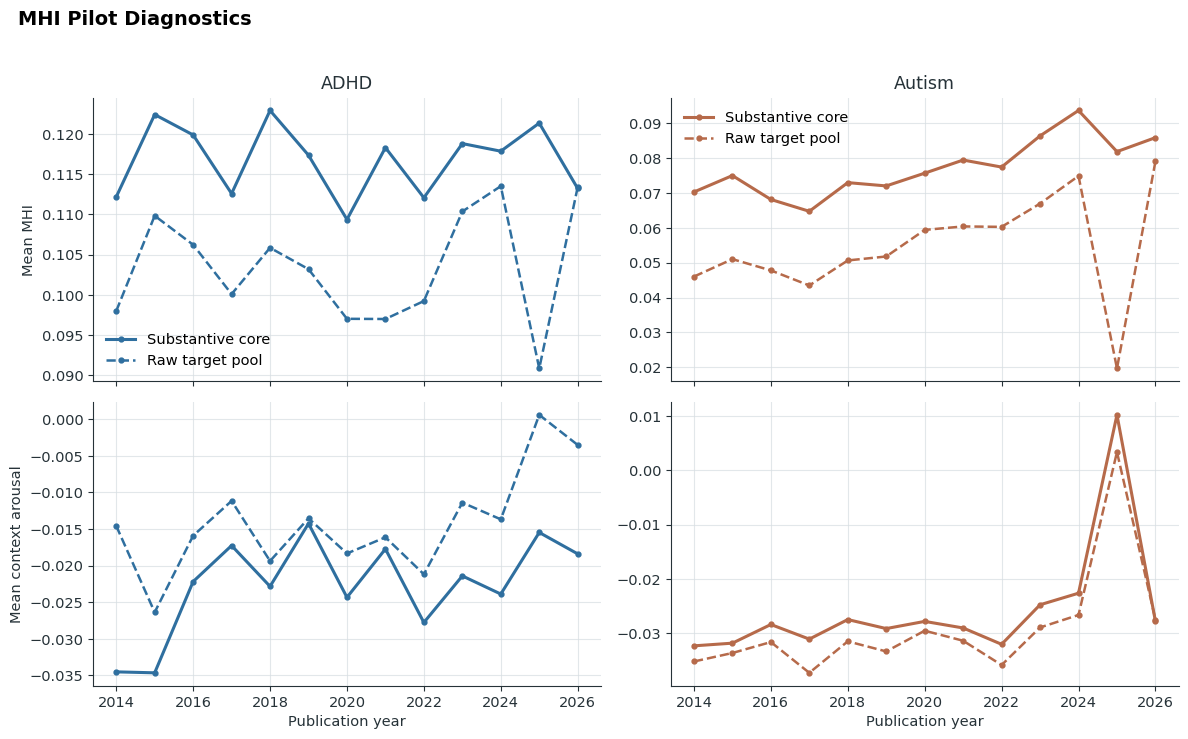

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True)
units = TARGET_UNITS
population_styles = {
    "substantive_core": {"label": "Substantive core", "linestyle": "-", "linewidth": 2.2},
    "raw_target_pool": {"label": "Raw target pool", "linestyle": "--", "linewidth": 1.8},
}
unit_colors = {"ADHD": "#2F6F9F", "Autism": "#B66A4A"}

for col, unit in enumerate(units):
    unit_data = annual_diagnostics.loc[annual_diagnostics["analysis_unit"].eq(unit)]
    for population, style in population_styles.items():
        series = unit_data.loc[unit_data["model_population"].eq(population)].sort_values("lsc_year")
        axes[0, col].plot(
            series["lsc_year"],
            series["mhi_mean"],
            color=unit_colors[unit],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            marker="o",
            markersize=3.5,
            label=style["label"],
        )
        axes[1, col].plot(
            series["lsc_year"],
            series["arousal_mean"],
            color=unit_colors[unit],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            marker="o",
            markersize=3.5,
            label=style["label"],
        )
    axes[0, col].set_title(unit)
    axes[0, col].set_ylabel("Mean MHI" if col == 0 else "")
    axes[1, col].set_ylabel("Mean context arousal" if col == 0 else "")
    axes[1, col].set_xlabel("Publication year")
    axes[0, col].legend(loc="best")

fig.suptitle("MHI Pilot Diagnostics", fontsize=14, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(ANNUAL_FIGURE_PATH, dpi=LSC_FIGURE_DPI, bbox_inches="tight")
fig.savefig(ANNUAL_FIGURE_PDF_PATH, bbox_inches="tight")
plt.show()


## Execution Summary

The key table below compares the unadjusted year slope with the MHI-adjusted year slope for the primary substantive-core model and raw-pool sensitivity.


In [13]:
overall_slopes = model_summary_table.loc[
    model_summary_table["model_scope"].eq("overall")
    & model_summary_table["formula_name"].isin(["arousal ~ year", "arousal ~ year + MHI"]),
    [
        "model_population",
        "analysis_unit",
        "formula_name",
        "n_contexts",
        "n_documents",
        "year_slope_per_year",
        "year_slope_p_value",
        "mhi_z_coefficient",
        "mhi_z_p_value",
        "adj_r_squared",
    ],
].copy()

slope_wide = overall_slopes.pivot_table(
    index=["model_population", "analysis_unit"],
    columns="formula_name",
    values="year_slope_per_year",
    aggfunc="first",
).reset_index()
slope_wide["mhi_adjusted_minus_unadjusted"] = slope_wide["arousal ~ year + MHI"] - slope_wide["arousal ~ year"]
slope_wide["relative_absolute_attenuation"] = 1 - (
    slope_wide["arousal ~ year + MHI"].abs() / slope_wide["arousal ~ year"].abs()
)

execution_summary = {
    "token_cache_status": token_cache_status,
    "model_cache_status": model_cache_status,
    "raw_arousal_cache_status": raw_arousal_cache_status,
    "word2vec_params": WORD2VEC_PARAMS,
    "pisl_seed_words": PISL_MENTAL_SEEDS,
    "present_seed_words": seed_diagnostics.loc[seed_diagnostics["in_vocabulary"], "seed"].tolist(),
    "missing_seed_words": seed_diagnostics.loc[~seed_diagnostics["in_vocabulary"], "seed"].tolist(),
    "token_summary": token_summary,
    "model_summary": model_summary,
    "primary_context_rows": int(len(primary_model_input)),
    "raw_context_rows": int(len(raw_model_input)),
    "outputs": {
        "context_scores": str(CONTEXT_SCORES_PATH),
        "primary_model_input": str(PRIMARY_MODEL_INPUT_PATH),
        "raw_model_input": str(RAW_MODEL_INPUT_PATH),
        "annual_diagnostics": str(ANNUAL_DIAGNOSTICS_PATH),
        "frame_diagnostics": str(FRAME_DIAGNOSTICS_PATH),
        "model_summary": str(MODEL_SUMMARY_PATH),
        "model_coefficients": str(MODEL_COEFFICIENTS_PATH),
        "bootstrap_summary": str(BOOTSTRAP_SUMMARY_PATH),
        "annual_figure": str(ANNUAL_FIGURE_PATH),
    },
}
EXECUTION_SUMMARY_PATH.write_text(json.dumps(execution_summary, indent=2, sort_keys=True) + "\n")

slope_wide


formula_name,model_population,analysis_unit,arousal ~ year,arousal ~ year + MHI,mhi_adjusted_minus_unadjusted,relative_absolute_attenuation
0,raw_target_pool,ADHD,0.000822,0.000813,-0.000009,0.010760
1,raw_target_pool,Autism,0.001648,0.001465,-0.000183,0.110878
2,substantive_core,ADHD,0.000945,0.000949,0.000004,-0.004001
3,substantive_core,Autism,0.001572,0.001140,-0.000432,0.274970
